# Práctica Nro. 7

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/manuxch/calculo_avanzado/blob/main/07-autovalores-autovectores/code/practica_07.ipynb)

## Ejercicio 1

Para comprobar que $\vec{v}$ es un autovector de $A$, debe cumplirse que:
$$ A \vec{v} = \lambda \vec{v} $$
Hacemos el producto de $A$ por $\vec{v}$:
$$ \begin{bmatrix} 53 & -70 \\ 35 & -46 \end{bmatrix} \cdot \begin{bmatrix} 7 \\ 5 \end{bmatrix} = 
\begin{bmatrix} 21 \\ 15 \end{bmatrix} $$
Podemos ver que el resultado lo podemos escribir como
$$ \begin{bmatrix} 21 \\ 15 \end{bmatrix} = 3 \begin{bmatrix} 7 \\ 5 \end{bmatrix} $$
por lo tanto 
$$ \begin{bmatrix} 53 & -70 \\ 35 & -46 \end{bmatrix} \cdot \begin{bmatrix} 7 \\ 5 \end{bmatrix} = 
3 \begin{bmatrix} 7 \\ 5 \end{bmatrix} $$
lo que muestra que $\vec{v}$ es un autovector de $A$ con autovalor $\lambda = 3$.

El módulo `SymPy` de Python permite la manipulación de matrices y el cálculo de sus autovalores y autovectores:

In [1]:
from sympy import Matrix, pprint
A = Matrix([[53, -70], [35, -46]]) # Definimos la matriz A
v = Matrix([7, 5])                 # Definimos el vector v como matriz columna
print(A.eigenvals())               # Mostramos los autovalores de A

{4: 1, 3: 1}


Lo que resulta es un un **diccionario** (notar que está delimitado por llaves) cuyas claves son 
los autovalores de $A$, y como valor encontramos la multiplicidad del autovalor. Recordar que los
autovalores son las raíces del polinomio característico, y es posible que un polinomio tenga raíces
múltiples. En este caso, como la matriz $A$ es $2 \times 2$, el polinomio caracteríostico es de segundo grado, por lo que tiene dos raíces, una de ellas (3) es la que hallamos al verificar el autovector.

Para hallar los autovalores hacemos lo siguiente:

In [2]:
sol = A.eigenvects()
for s in sol:
    print(s[0])
    pprint(s[2][0])

3
⎡7/5⎤
⎢   ⎥
⎣ 1 ⎦
4
⎡10/7⎤
⎢    ⎥
⎣ 1  ⎦


La salida de `eigenvects()` consiste en una lista con dos elementos, una por cada autovalor. A su vez, cada elemento es una tupla que contiene al autovalor, su multiplicidad, y el autovector asociado, en ese orden.

Notar que los autovectores se muestran con una de las componentes con valor $1$. 

## Ejercicio 3

Si $\vec{u}$ y $\vec{v}$ son autovectores de $A$ asociados a $\lambda$, tenemos que 
$A \vec{u} = \lambda \vec{u}$ y $A \vec{v} = \lambda \vec{v}$. Entonces:

a) 
$$ A \cdot(\vec{u} + \vec{v}) = A \vec{u} + A \vec{v} = \lambda \vec{u} + \lambda \vec{v} = 
\lambda (\vec{u} + \vec{v}) $$
Por lo tanto $\vec{u} + \vec{v}$ es un autovector de $A$ con autovalor asociado $\lambda$.

b)
$$ 3 A \cdot \vec{v} = 3 \cdot A \vec{v} = 3 \lambda \vec{v} $$
por lo que $\vec{v}$ es un autovector de $3A$ con autovalor $3 \lambda$.

## Ejercicio 4

El teorema del círculo de Gerschgorin establece que los autovalores se hallan en las regiones delimitadas por 
círculos del plano complejo cuyos centros están sobre el eje real, ubicados en los valores de la diagonal de la matriz, y los radios se hallan, para cada centro, sumando los valores absolutos de los demás elementos de la fila (excepto los valores sobre la diagonal). 

En este caso, dada la matriz
$$ \begin{bmatrix} 1 & 2 & -1 \\ 2 & 7 & 0 \\ -1 & 0 & 5 \end{bmatrix} $$
los centros se ubican en los valores $c_1 = 1, c_2 = 7, c_3 = 5$, mientras que los radios para cada centro son:
$$ \begin{align*}
r_1 &= |2| + |-1| = 3 \\
r_2 &= |2| + |0| = 2 \\
r_3 &= |-1| + |0| = 1
\end{align*} $$
Podemos utilizar el módulo `matplotlib`  de Python para graficar estos círculos:

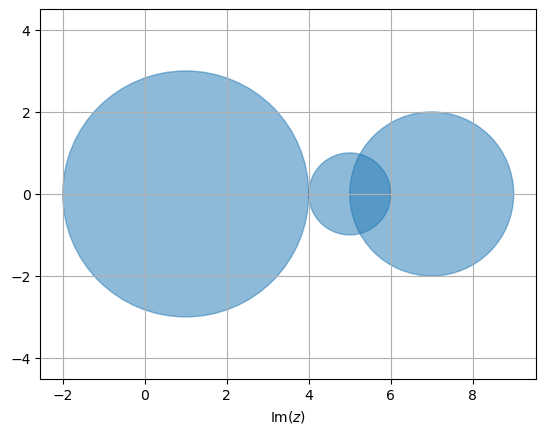

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
alfa = 0.5 # Transparencia de los círculos
c1 = plt.Circle((1, 0), 3, color='tab:blue', alpha = alfa) 
c2 = plt.Circle((7, 0), 2, color='tab:blue', alpha = alfa) 
c3 = plt.Circle((5, 0), 1, color='tab:blue', alpha = alfa) 
ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)
ax.set_xlabel(r'Re$(z)$')
ax.set_xlabel(r'Im$(z)$')
plt.grid()
plt.axis('equal')
plt.show()

Podemos ver que los círculos definen una región que comprende los valores reales entre $-2$ y $9$, por lo que
$$ \sigma(A) \subset [-2, 9] $$

## Ejercicio 5

Para hallar los autovalores de la matriz $A$, hay que encontrar las raíces del polinomio característico:
$$ 
\begin{align*} |(A - \lambda I)| &= 
\left| \begin{bmatrix} -13 & 20 \\ -12 & 18 \end{bmatrix} - \lambda \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} \right| 
= \left| \begin{bmatrix} -13 - \lambda & 20 \\ -12 & 18 - \lambda \end{bmatrix} \right| \\
&= (-13 - \lambda) (18 - \lambda) - 20 (-12) \\
&= \lambda^2 - 5 \lambda + 6 = (\lambda - 2) (\lambda - 3)
\end{align*} $$
Las raíces resultan, entonces, $\lambda_1 = 3, \lambda_2 = 2$, o equivalentemente, el espectro de $A$ es 
$\sigma(A) = \{2, 3\}$.

Para el autovalor $\lambda_1 = 2$, el autovector correspondiente resulta de resolver el sistema:
$$ \begin{bmatrix} -13 - 2 & 20 \\ -12 & 18 - 2 \end{bmatrix} \begin{bmatrix} v_x \\ v_y \end{bmatrix} = 
\begin{bmatrix} 0 \\ 0 \end{bmatrix} $$
que consiste en el sistema de ecuaciones:
$$ \begin{align*}
-15 v_x + 20 v_y &= 0 \\
-12 v_x + 16 v_y &= 0
\end{align*} $$
De la primera ecuación tenemos:
$$v_x = \frac{4}{3} v_y $$
reemplazando en la segunda:
$$ -12 \frac{4}{3} v_y + 16 v_y = -16 v_y + 16 v_y = 0$$
Se cumple para cualquier valor de $v_y$, por lo que podemos elegir como solución $v_y = 3, v_x = 4$ y nuestro autovector correspondiente al autovalor $\lambda_1 = 2$ resulta $\vec{v}_1 = [4, 3]^{\intercal}$. Del mismo modo, para el autovalor
$\lambda_2 = 3$ el autovector asociado es $\vec{v}_2 = [5, 4]^{\intercal}$.

Nuevamente, podemos hacer uso del módulo `SymPy` para que haga los cálculos por nosotros:

In [4]:
from sympy import Matrix, pprint
A = Matrix([[-13, 20], [-12, 18]])
sol = A.eigenvects()
for s in sol:
    print(f'Autovalor {s[0]}, autovector:')
    pprint(s[2][0])


Autovalor 2, autovector:
⎡4/3⎤
⎢   ⎥
⎣ 1 ⎦
Autovalor 3, autovector:
⎡5/4⎤
⎢   ⎥
⎣ 1 ⎦


## Ejercicio 7

Para resolver este ejercicio vamos a escribir una función en Python que implemente el método de las potencias, dado que resolver _a mano_ cada problema se vuelve una tarea muy tediosa.

In [5]:
import numpy as np

def metodo_potencia(A, num_iteraciones):
    """Función que implementa el método de la potencia
    para determinar el autovalor dominante y su correspondiente
    autovector.

    Parameters:
    A (numpy array): Matriz 
    num_iteraciones (int): Número de iteraciones

    Returns:
    autovalor (double): Autovalor domintante
    x (numpy array): Autovector correspondiente
    """
    n = A.shape[0] # Cantidad de filas de A
    # Inicializamos un vector con componentes aleatorias de dimensión n
    x = np.random.rand(n)
    # Normalizamos el vector
    x = x / np.linalg.norm(x)

    for _ in range(num_iteraciones):
        y = np.dot(A, x)
        # Obtenemos la norma máxima
        y_abs = np.abs(y)
        autovalor = y_abs.max()
        # Normalizamos el vector resultante
        x = y / autovalor
    # Devolvemos el autovalor dominante y su autovector
    return autovalor, x
    

Ahora definimos las matrices a las que les aplicaremos el método de las potencias. Recordemos que podemos representar una matriz como un array de numpy compuesto de tantos elementos como filas tenga la matriz, y en la que cada elemento a su vez tiene tantos elementos como columnas de la matriz.

In [6]:
A = np.array([[4, 2, 4], [3, 0 , 4], [1, 2, 5]])
B = np.array([[0, 1, 0, 1, 0],
              [1, 0, 1, 0, 1],
              [0, 1, 0, 1, 0],
              [1, 0, 1, 0, 1],
              [0, 1, 0, 1, 0]])
C = np.array([[1, 2, 3, 4, 5, 6],
              [7, 8, 9, 10, 11, 12],
              [13, 14, 15, 16, 17, 18],
              [19, 20, 21, 22, 23, 24],
              [25, 26, 27, 28, 29, 30],
              [31, 32, 33, 34, 35, 36]])

Para poder hacer los cálculos iterando sobre las matrices, las organizamos dentro de un diccionario de Python:

In [7]:
matrices = {'A': A, 'B': B, 'C':C}

Ahora iteramos sobre este diccionario, aplicando el método de las potencias sobre cada elemento:

In [8]:
n_iter = 50
for matriz in matrices.keys():
    autoval, autovec = metodo_potencia(matrices[matriz], n_iter)
    print(80 * '-')
    print(f"Autovalor dominante de {matriz} = {autoval}")
    print("Autovector asociado:")
    print(autovec)

--------------------------------------------------------------------------------
Autovalor dominante de A = 8.32718457554116
Autovector asociado:
[1.         0.70950456 0.72704386]
--------------------------------------------------------------------------------
Autovalor dominante de B = 2.0
Autovector asociado:
[1.         0.73404474 1.         0.73404474 1.        ]
--------------------------------------------------------------------------------
Autovalor dominante de C = 116.41182151274086
Autovector asociado:
[0.12795692 0.30236554 0.47677415 0.65118277 0.82559138 1.        ]


## Ejercicio 13

**Planteamiento del sistema físico**

Se considera el sistema mecánico de la figura, compuesto por tres masas deslizantes sobre una superficie horizontal sin fricción, acopladas mediante resortes lineales y ancladas a paredes fijas en los extremos.

```
pared ──[k₁]──► m₁ ──[k₂]──► m₂ ──[k₃]──► m₃ ──[k₄]──► pared
```

Sean $x_1(t)$, $x_2(t)$ y $x_3(t)$ los desplazamientos de cada masa respecto a su posición de equilibrio estático (positivo hacia la derecha).

#### 1. Ecuaciones de movimiento

Aplicamos la Segunda Ley de Newton a cada masa, analizando las fuerzas de resorte que actúan sobre cada una.

#### Masa $m_1$

Fuerzas que actúan sobre $m_1$:
- Resorte $k_1$ (izquierda): empuja hacia la izquierda con magnitud $k_1 x_1$ (se estira si $x_1 > 0$).
- Resorte $k_2$ (derecha): la fuerza depende de la elongación relativa $(x_2 - x_1)$. Si $x_1 > x_2$, el resorte empuja $m_1$ hacia la derecha.

Por lo tanto:

$$m_1 \ddot{x}_1 = -k_1 x_1 + k_2(x_2 - x_1) = -(k_1 + k_2)x_1 + k_2 x_2$$

#### Masa $m_2$

Fuerzas que actúan sobre $m_2$:
- Resorte $k_2$ (izquierda): fuerza $k_2(x_1 - x_2)$ (empuja hacia la izquierda si $x_2 > x_1$).
- Resorte $k_3$ (derecha): fuerza $k_3(x_3 - x_2)$.

$$m_2 \ddot{x}_2 = k_2(x_1 - x_2) - k_3(x_2 - x_3) = k_2 x_1 - (k_2 + k_3)x_2 + k_3 x_3$$

#### Masa $m_3$

Fuerzas que actúan sobre $m_3$:
- Resorte $k_3$ (izquierda): fuerza $k_3(x_2 - x_3)$.
- Resorte $k_4$ (derecha, anclado a pared): fuerza $-k_4 x_3$.

$$m_3 \ddot{x}_3 = k_3(x_2 - x_3) - k_4 x_3 = k_3 x_2 - (k_3 + k_4)x_3$$

**Forma matricial del sistema**

Definimos el vector de desplazamientos $\mathbf{x}(t) = [x_1(t),\ x_2(t),\ x_3(t)]^T$. El sistema se escribe como:

$$M \ddot{\mathbf{x}}(t) + K \mathbf{x}(t) = \mathbf{0}$$

donde $M$ es la **matriz de masa** (diagonal, simétrica, definida positiva) y $K$ es la **matriz de rigidez** (tridiagonal simétrica, definida positiva):

$$M = \begin{bmatrix} m_1 & 0 & 0 \\ 0 & m_2 & 0 \\ 0 & 0 & m_3 \end{bmatrix}, \qquad K = \begin{bmatrix} k_1+k_2 & -k_2 & 0 \\ -k_2 & k_2+k_3 & -k_3 \\ 0 & -k_3 & k_3+k_4 \end{bmatrix}$$

### 2. Problema de autovalores

**Hipótesis de vibración armónica**

Buscamos **modos normales** de vibración: soluciones en las que todas las masas oscilan con la **misma frecuencia** $\omega$ y la **misma fase**, pero con **amplitudes diferentes** (posiblemente con signos opuestos):

$$\mathbf{x}(t) = \mathbf{u}\, e^{i\omega t}$$

donde $\mathbf{u} = [u_1,\ u_2,\ u_3]^T$ es un vector de amplitudes constantes (la **forma modal**).

Derivando dos veces respecto al tiempo:

$$\ddot{\mathbf{x}}(t) = -\omega^2 \mathbf{u}\, e^{i\omega t}$$

**Sustitución en la ecuación matricial**

Reemplazamos en $M\ddot{\mathbf{x}} + K\mathbf{x} = \mathbf{0}$:

$$M(-\omega^2 \mathbf{u}\, e^{i\omega t}) + K(\mathbf{u}\, e^{i\omega t}) = \mathbf{0}$$

El factor $e^{i\omega t}$ nunca se anula, por lo que podemos dividir toda la ecuación por él:

$$-\omega^2 M \mathbf{u} + K \mathbf{u} = \mathbf{0}$$

Reordenando:

$$\boxed{K\mathbf{u} = \omega^2 M\mathbf{u}}$$

**Definición del problema de autovalores generalizado**

Definiendo $\lambda = \omega^2$, obtenemos el **problema de autovalores generalizado**:

$$\boxed{K\mathbf{u} = \lambda M\mathbf{u}}$$

Si $M$ es invertible (lo es, pues es diagonal con elementos positivos), podemos premultiplicar por $M^{-1}$:

$$M^{-1}K\mathbf{u} = \lambda \mathbf{u}$$

o, de forma equivalente, definiendo $A = M^{-1}K$:

$$A\mathbf{u} = \lambda \mathbf{u}$$

Esta es la forma estándar del problema de autovalores.

**Interpretación física**

| Magnitud | Significado físico |
|----------|-------------------|
| $\lambda = \omega^2$ | **Autovalor**: frecuencia natural al cuadrado |
| $\omega = \sqrt{\lambda}$ | Frecuencia natural del modo (rad/s) |
| $\mathbf{u}$ | **Autovector**: forma modal (amplitudes relativas de cada masa) |

Cada par $(\lambda_n, \mathbf{u}^{(n)})$ define un **modo normal de vibración**: una configuración de desplazamientos que el sistema puede mantener oscilando armónicamente a una única frecuencia $\omega_n$.

Ahora vamos a utilizar Python para resolver algunas cosas.

In [9]:
# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
import sympy as sp
from sympy import symbols, Function, Eq, dsolve, Matrix, sqrt, simplify, latex, cos, sin

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

# Para mostrar ecuaciones simbólicas en Jupyter
sp.init_printing(use_latex='mathjax')

In [10]:
# Datos numéricos
m1, m2, m3 = 1.0, 2.0, 1.5
k1, k2, k3, k4 = 20.0, 15.0, 10.0, 25.0

# Matriz de masa M
M = np.array([[m1, 0, 0],
              [0, m2, 0],
              [0, 0, m3]])

# Matriz de rigidez K
K = np.array([[k1 + k2,   -k2,      0],
              [  -k2,   k2 + k3,   -k3],
              [    0,      -k3,   k3 + k4]])

print("Matriz de masa M:")
print(M)
print("\nMatriz de rigidez K:")
print(K)

# Verificación: K es simétrica
print("\nK es simétrica?", np.allclose(K, K.T))
print("M es diagonal?", np.allclose(M, np.diag(np.diag(M))))

Matriz de masa M:
[[1.  0.  0. ]
 [0.  2.  0. ]
 [0.  0.  1.5]]

Matriz de rigidez K:
[[ 35. -15.   0.]
 [-15.  25. -10.]
 [  0. -10.  35.]]

K es simétrica? True
M es diagonal? True


**Derivación simbólica del polinomio característico**

A continuación usamos `sympy` para obtener simbólicamente el polinomio característico $\det(K - \lambda M) = 0$ con los valores numéricos del problema.

In [11]:
# Definir símbolos para masas y rigideces
m1s, m2s, m3s = sp.symbols('m_1 m_2 m_3', positive=True, real=True)
k1s, k2s, k3s, k4s = sp.symbols('k_1 k_2 k_3 k_4', positive=True, real=True)
lam = sp.symbols('lambda', real=True, positive=True)

# Matriz de masa simbólica
Ms_sym = sp.Matrix([[m1s, 0, 0],
                    [0, m2s, 0],
                    [0, 0, m3s]])

# Matriz de rigidez simbólica
Ks_sym = sp.Matrix([[k1s + k2s, -k2s, 0],
                    [-k2s, k2s + k3s, -k3s],
                    [0, -k3s, k3s + k4s]])

print("=== FORMA SIMBÓLICA GENERAL ===\n")
print("Matriz de masa M:")
display(Ms_sym)

print("\nMatriz de rigidez K:")
display(Ks_sym)

# Matriz característica K - λM (forma simbólica general)
char_matrix_sym = Ks_sym - lam * Ms_sym
print("\nMatriz característica K - λM (forma general):")
display(char_matrix_sym)

# ============================================
# Sustitución de valores numéricos
# ============================================

# Diccionario de valores numéricos (como racionales para precisión simbólica)
vals = {m1s: sp.Rational(1), m2s: sp.Rational(2), m3s: sp.Rational(3,2),
        k1s: sp.Rational(20), k2s: sp.Rational(15),
        k3s: sp.Rational(10), k4s: sp.Rational(25)}

# Matrices con valores numéricos exactos
Ms_num = Ms_sym.subs(vals)
Ks_num = Ks_sym.subs(vals)
char_matrix_num = char_matrix_sym.subs(vals)

print("\n=== CON VALORES NUMÉRICOS EXACTOS ===\n")
print("M =")
display(Ms_num)
print("\nK =")
display(Ks_num)
print("\nK - λM =")
display(char_matrix_num)

# Polinomio característico det(K - λM) = 0
char_poly = char_matrix_num.det()
char_poly_expanded = sp.expand(char_poly)
print("\nPolinomio característico det(K - λM) = 0:")
display(sp.Eq(char_poly_expanded, 0))

# Obtener raíces numéricas (nroots es robusto para polinomios)
poly = sp.Poly(char_poly_expanded, lam)
eigenvals_n = poly.nroots()
eigenvals_n = sorted([complex(ev) for ev in eigenvals_n], key=lambda x: x.real)

print("\nAutovalores (λ = ω²) y frecuencias naturales:")
for i, ev in enumerate(eigenvals_n):
    ev_real = float(ev.real)
    omega_val = float(sp.sqrt(ev_real))
    print(f"  λ_{i+1} = {ev_real:.6f}  →  ω_{i+1} = {omega_val:.6f} rad/s")

=== FORMA SIMBÓLICA GENERAL ===

Matriz de masa M:


⎡m₁  0   0 ⎤
⎢          ⎥
⎢0   m₂  0 ⎥
⎢          ⎥
⎣0   0   m₃⎦


Matriz de rigidez K:


⎡k₁ + k₂    -k₂       0   ⎤
⎢                         ⎥
⎢  -k₂    k₂ + k₃    -k₃  ⎥
⎢                         ⎥
⎣   0       -k₃    k₃ + k₄⎦


Matriz característica K - λM (forma general):


...


K - λM =


⎡35 - λ    -15        0    ⎤
⎢                          ⎥
⎢ -15    25 - 2⋅λ    -10   ⎥
⎢                          ⎥
⎢                       3⋅λ⎥
⎢  0       -10     35 - ───⎥
⎣                        2 ⎦


Polinomio característico det(K - λM) = 0:


              2                     
     3   425⋅λ                      
- 3⋅λ  + ────── - 4200⋅λ + 19250 = 0
           2                        


Autovalores (λ = ω²) y frecuencias naturales:
  λ_1 = 6.557632  →  ω_1 = 2.560787 rad/s
  λ_2 = 24.766430  →  ω_2 = 4.976588 rad/s
  λ_3 = 39.509271  →  ω_3 = 6.285640 rad/s


### 3. Solución numérica del problema de autovalores

Resolvemos $K\mathbf{u} = \lambda M\mathbf{u}$ utilizando `scipy.linalg.eig`, que resuelve directamente el problema generalizado.

In [12]:
# Resolver problema de autovalores generalizado: K u = lambda * M u
eigenvalues, eigenvectors = eig(K, M)

# Ordenar de menor a mayor frecuencia
idx = np.argsort(eigenvalues)
eigenvalues = np.real(eigenvalues[idx])
eigenvectors = eigenvectors[:, idx]

# Frecuencias naturales y periodos
omega = np.sqrt(eigenvalues)
T = 2 * np.pi / omega
f = omega / (2 * np.pi)

print("=== RESULTADOS DEL PROBLEMA DE AUTOVALORES ===\n")
for i in range(3):
    print(f"Modo {i+1}:")
    print(f"  λ_{i+1} = {eigenvalues[i]:.6f} (rad/s)²")
    print(f"  ω_{i+1} = {omega[i]:.6f} rad/s")
    print(f"  f_{i+1} = {f[i]:.6f} Hz")
    print(f"  T_{i+1} = {T[i]:.6f} s")
    print(f"  u^{i+1} = {np.real(eigenvectors[:, i])}")
    print()

=== RESULTADOS DEL PROBLEMA DE AUTOVALORES ===

Modo 1:
  λ_1 = 6.557632 (rad/s)²
  ω_1 = 2.560787 rad/s
  f_1 = 0.407562 Hz
  T_1 = 2.453615 s
  u^1 = [-0.4401 -0.8345 -0.3316]

Modo 2:
  λ_2 = 24.766430 (rad/s)²
  ω_2 = 4.976588 rad/s
  f_2 = 0.792049 Hz
  T_2 = 1.262549 s
  u^2 = [-0.2944 -0.2008  0.9343]

Modo 3:
  λ_3 = 39.509271 (rad/s)²
  ω_3 = 6.285640 rad/s
  f_3 = 1.000391 Hz
  T_3 = 0.999609 s
  u^3 = [-0.951   0.2859 -0.1178]



### 4. Normalización de los modos normales

#### ¿En qué consiste?

Los autovectores que devuelve cualquier rutina numérica (como `scipy.linalg.eig`) están definidos **salvo una constante multiplicativa**: si $\mathbf{u}$ es autovector, entonces $c\mathbf{u}$ también lo es para cualquier escalar $c \neq 0$. Esto significa que las amplitudes relativas de las masas en un modo son únicas, pero su **magnitud absoluta** es arbitraria.

Para remover esa arbitrariedad y obtener una base única, se impone una condición de normalización. La más natural en vibraciones mecánicas es la **normalización respecto a la matriz de masa** (también llamada *ortogonalización de Gram--Schmidt generalizada*):

$$\phi^{(n)} = \frac{\mathbf{u}^{(n)}}{\sqrt{\mathbf{u}^{(n)T} \; M \; \mathbf{u}^{(n)}}}$$

De este modo, cada modo normalizado $\phi^{(n)}$ satisface:

$$\bigl(\phi^{(n)}\bigr)^T M \; \phi^{(n)} = 1$$

y, como consecuencia directa de la ecuación de autovalores:

$$\bigl(\phi^{(n)}\bigr)^T K \; \phi^{(n)} = \omega_n^2.$$

#### ¿Por qué se hace?

La normalización por masa tiene tres motivaciones fundamentales:

1. **Desacoplamiento del sistema.** Si agrupamos los tres modos normalizados en una matriz modal $\Phi = [\phi^{(1)} \; \phi^{(2)} \; \phi^{(3)}]$, entonces las ecuaciones de movimiento se transforman en coordenadas modales $\mathbf{q}(t)$ mediante $\mathbf{x}(t) = \Phi \mathbf{q}(t)$. Gracias a la normalización, las matrices transformadas son **diagonales**:
   $$\Phi^T M \Phi = I \qquad \text{y} \qquad \Phi^T K \Phi = \Omega^2 = \text{diag}(\omega_1^2, \omega_2^2, \omega_3^2).$$
   El sistema de 3 ecuaciones acopladas se convierte en **3 osciladores armónicos independientes**: $\ddot{q}_n + \omega_n^2 q_n = 0$.

2. **Energía cinética unitaria.** La forma cuadrática $\mathbf{u}^T M \mathbf{u}$ representa el doble de la energía cinética del sistema cuando las masas se mueven con velocidades proporcionales a $\mathbf{u}$. Imponer $\phi^T M \phi = 1$ equivale a fijar una **energía cinética de referencia unitaria** para cada modo, lo que simplifica los cálculos de respuesta forzada y condiciones iniciales.

3. **Unicidad y comparabilidad.** Al fijar la norma, los modos de distintos sistemas (o de distintas versiones del mismo modelo) pueden compararse directamente. Además, las coordenadas modales $q_n(t)$ adquieren unidades de longitud y pueden interpretarse como "amplitudes de participación" de cada modo en el movimiento total.

#### ¿Cómo se interpretan los resultados?

- **Signo de las componentes:** Si dos masas tienen el mismo signo en un autovector, oscilan **en fase** en ese modo; si tienen signos opuestos, lo hacen en **contrafase**. La magnitud indica la amplitud relativa.

- **Masa generalizada:** Aunque los modos están normalizados, si se desea recuperar la forma física original (por ejemplo, para comparar con mediciones experimentales), basta con multiplicar por cualquier factor de escala. La masa generalizada $m_n^* = \phi^{(n)T} M \phi^{(n)} = 1$ actúa como factor de conversión natural.

- **Factor de participación modal:** Dada una condición inicial $\mathbf{x}(0)$, la proyección sobre el modo $n$ es $q_n(0) = \phi^{(n)T} M \mathbf{x}(0)$. Gracias a la normalización, esta proyección está bien definida y no depende de la escala arbitraria del autovector crudo.

En resumen: normalizar por la masa no es un mero truco algebraico, sino la elección que garantiza que la transformación modal sea una **base ortonormal en el espacio de energía cinética**, haciendo posible el análisis modal como herramienta de diseño e interpretación física.

In [13]:
# Normalizar modos respecto a M: phi^T M phi = 1
Phi = np.zeros_like(eigenvectors)
for i in range(3):
    u = np.real(eigenvectors[:, i])
    norm = np.sqrt(u.T @ M @ u)
    Phi[:, i] = u / norm

print("Matriz modal Φ (columnas = modos normalizados):")
print(np.round(Phi, 4))

# Verificación de ortogonalidad
print("\nVerificación Φ^T M Φ = I:")
print(np.round(Phi.T @ M @ Phi, 6))

print("\nVerificación Φ^T K Φ = Ω² (diagonal de autovalores):")
print(np.round(Phi.T @ K @ Phi, 4))

Matriz modal Φ (columnas = modos normalizados):
[[-0.3325 -0.2423 -0.9114]
 [-0.6306 -0.1653  0.274 ]
 [-0.2506  0.7688 -0.1129]]

Verificación Φ^T M Φ = I:
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Verificación Φ^T K Φ = Ω² (diagonal de autovalores):
[[ 6.5576 -0.     -0.    ]
 [-0.     24.7664 -0.    ]
 [-0.     -0.     39.5093]]


### 5. Interpretación física

**Visualización de los modos normales**

Cada gráfico muestra la forma modal: la amplitud relativa de desplazamiento de cada masa en ese modo.

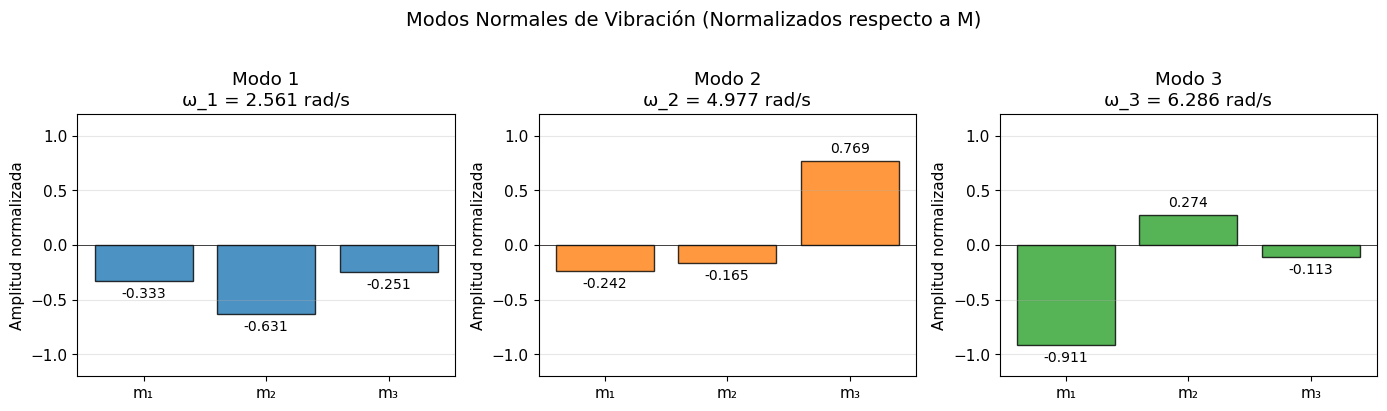

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
masses = np.array([1, 2, 3])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, ax in enumerate(axes):
    mode = Phi[:, i]
    ax.bar(masses, mode, color=colors[i], edgecolor='black', alpha=0.8)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_xticks(masses)
    ax.set_xticklabels(['m₁', 'm₂', 'm₃'])
    ax.set_ylabel('Amplitud normalizada')
    ax.set_title(f'Modo {i+1}\nω_{i+1} = {omega[i]:.3f} rad/s')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(-1.2, 1.2)
    for j, v in enumerate(mode):
        ax.text(j+1, v + 0.05*np.sign(v) if v != 0 else 0.05, f'{v:.3f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

plt.suptitle('Modos Normales de Vibración (Normalizados respecto a M)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Representación esquemática de los modos**

Visualización de cómo se mueve cada masa en cada modo (línea de equilibrio punteada).

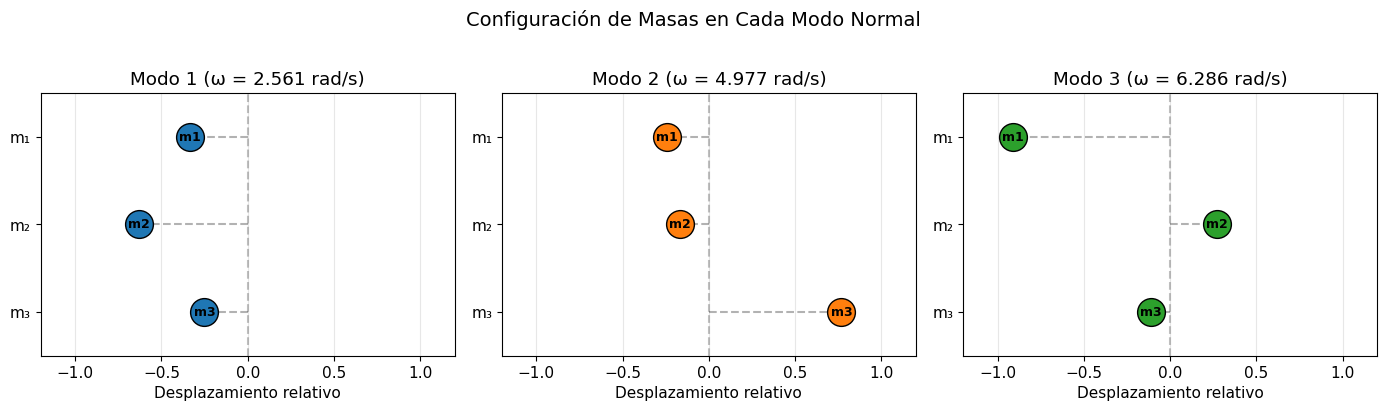

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axes):
    mode = Phi[:, i]
    y_pos = np.array([0, 1, 2])
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    for j in range(3):
        ax.scatter(mode[j], y_pos[j], s=400, c=colors[i], edgecolors='black', zorder=3)
        ax.text(mode[j], y_pos[j], f'm{j+1}', ha='center', va='center', fontsize=9, fontweight='bold')
        ax.plot([0, mode[j]], [y_pos[j], y_pos[j]], 'k--', alpha=0.3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(['m₁', 'm₂', 'm₃'])
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.5, 2.5)
    ax.set_xlabel('Desplazamiento relativo')
    ax.set_title(f'Modo {i+1} (ω = {omega[i]:.3f} rad/s)')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
plt.suptitle('Configuración de Masas en Cada Modo Normal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Animación de los modos normales**

A continuación se presenta una animación que muestra cómo oscilan las tres masas en cada modo normal de vibración. Cada panel corresponde a un modo, con las masas desplazándose armónicamente a la frecuencia natural correspondiente.

**Observaciones a notar:**
- **Modo 1:** Las tres masas se mueven en la misma dirección (fase), con amplitudes diferentes.
- **Modo 2:** $m_1$ y $m_2$ se mueven juntas en contrafase respecto a $m_3$; hay un nodo de vibración entre $m_2$ y $m_3$.
- **Modo 3:** Máxima complejidad con cambios de fase entre masas consecutivas; dos nodos de vibración.

Animación guardada en: animacion_modos_vibracion.gif


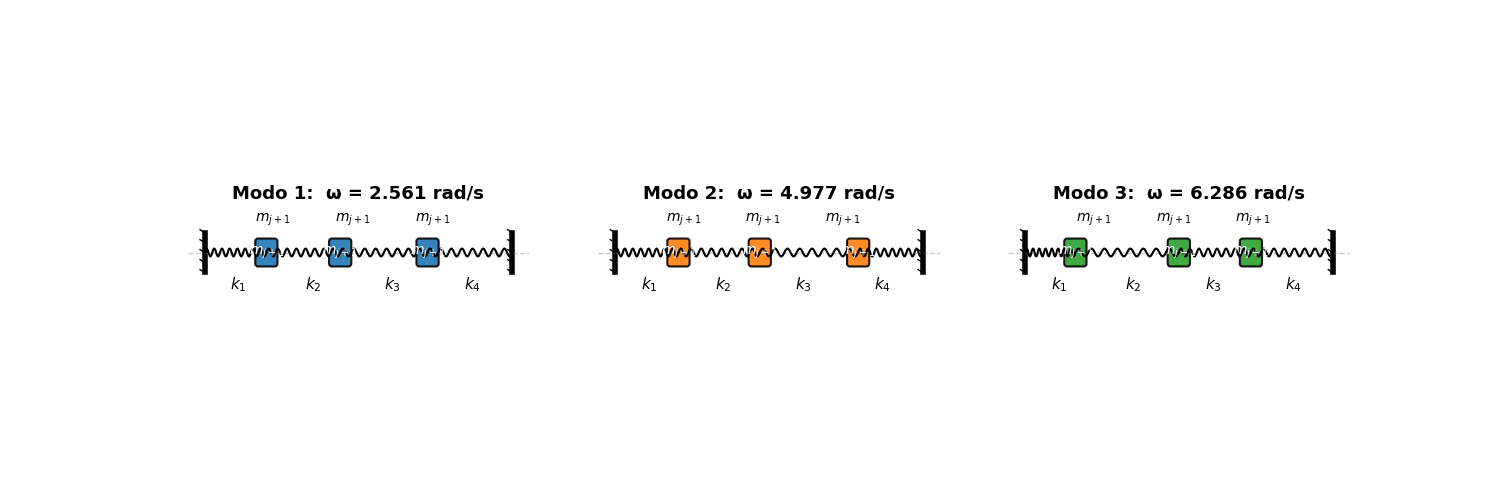

In [16]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch

# ============================================
# ANIMACIÓN DE MODOS NORMALES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Parámetros de dibujo
mass_width = 0.35
mass_height = 0.45
y_base = 0
x_eq = [1.2, 2.6, 4.0]       # posiciones de equilibrio
wall_left_x = 0
wall_right_x = 5.4
scale = 0.35                  # escala visual de amplitud

def draw_wall(ax, x, y, h=0.7):
    ax.plot([x, x], [y-h/2, y+h/2], 'k-', linewidth=4)
    for dy in np.linspace(-h/2, h/2, 5):
        ax.plot([x, x-0.08], [y+dy, y+dy+0.05], 'k-', linewidth=1)

def draw_spring(ax, x1, x2, y, n_coils=8, amplitude=0.07):
    x = np.linspace(x1, x2, 100)
    n_cycles = n_coils
    amp = amplitude
    y_spring = y + amp * np.sin(n_cycles * 2 * np.pi * (x - x1) / (x2 - x1 + 1e-9))
    ax.plot(x, y_spring, 'k-', linewidth=1.5)

def draw_mass(ax, x, y, w, h, color, label):
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.02,rounding_size=0.05",
                          facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Configurar ejes
for i, ax in enumerate(axes):
    ax.set_xlim(-0.3, 5.7)
    ax.set_ylim(-0.8, 0.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Modo {i+1}:  ω = {omega[i]:.3f} rad/s', fontsize=13, fontweight='bold')

def animate(frame):
    t = frame * 0.08
    for mode in range(3):
        ax = axes[mode]
        ax.clear()
        ax.set_xlim(-0.3, 5.7)
        ax.set_ylim(-0.8, 0.8)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f'Modo {mode+1}:  ω = {omega[mode]:.3f} rad/s',
                     fontsize=13, fontweight='bold')
        
        mode_shape = Phi[:, mode]
        w_mode = omega[mode]
        disp = scale * mode_shape * np.cos(w_mode * t)
        x_masses = [x_eq[j] + disp[j] for j in range(3)]
        
        # Paredes
        draw_wall(ax, wall_left_x, y_base)
        draw_wall(ax, wall_right_x, y_base)
        
        # Etiquetas k
        ax.text(0.6, -0.65, r'$k_1$', ha='center', fontsize=11)
        ax.text(1.9, -0.65, r'$k_2$', ha='center', fontsize=11)
        ax.text(3.3, -0.65, r'$k_3$', ha='center', fontsize=11)
        ax.text(4.7, -0.65, r'$k_4$', ha='center', fontsize=11)
        
        # Línea de equilibrio
        ax.axhline(y=y_base, color='gray', linestyle='--', alpha=0.4, linewidth=1)
        
        # Etiquetas de masa (estáticas)
        for j in range(3):
            ax.text(x_eq[j], y_base + 0.55, f'$m_{{j+1}}$',
                    ha='center', fontsize=10, color='black')
        
        # Resortes
        x_springs = [wall_left_x] + x_masses + [wall_right_x]
        for s in range(4):
            x1, x2 = x_springs[s], x_springs[s+1]
            draw_spring(ax, x1, x2, y_base)
        
        # Masas
        for j in range(3):
            draw_mass(ax, x_masses[j], y_base, mass_width, mass_height,
                      colors[mode], f'$m_{{j+1}}$')
    return []

n_frames = 200
anim = FuncAnimation(fig, animate, frames=n_frames, interval=50, blit=False)

# Guardar como GIF
output_gif = 'animacion_modos_vibracion.gif'
writer = PillowWriter(fps=20)
anim.save(output_gif, writer=writer)
plt.close()

print(f'Animación guardada en: {output_gif}')

# Mostrar en el notebook
from IPython.display import Image, display
display(Image(filename=output_gif))

### 6. Respuesta temporal

Cualquier movimiento libre del sistema puede expresarse como superposición de modos normales. Definimos las **coordenadas modales** $\mathbf{q}(t)$ mediante la transformación:

$$\mathbf{x}(t) = \Phi \mathbf{q}(t)$$

Sustituyendo en la ecuación de movimiento $M\ddot{\mathbf{x}} + K\mathbf{x} = \mathbf{0}$ y premultiplicando por $\Phi^T$:

$$\Phi^T M \Phi \ddot{\mathbf{q}} + \Phi^T K \Phi \mathbf{q} = \mathbf{0}$$

Dado que $\Phi^T M \Phi = I$ y $\Phi^T K \Phi = \Omega^2 = \text{diag}(\omega_1^2, \omega_2^2, \omega_3^2)$, obtenemos **tres ecuaciones desacopladas**:

$$\ddot{q}_n + \omega_n^2 q_n = 0, \qquad n = 1, 2, 3$$

La solución general de cada una es:

$$q_n(t) = q_n(0)\cos(\omega_n t) + \frac{\dot{q}_n(0)}{\omega_n}\sin(\omega_n t)$$

Las condiciones iniciales en coordenadas modales se obtienen proyectando las CI físicas sobre los modos normalizados:

$$\mathbf{q}(0) = \Phi^T M \mathbf{x}(0), \qquad \dot{\mathbf{q}}(0) = \Phi^T M \dot{\mathbf{x}}(0)$$

#### Datos del problema

Condiciones iniciales: $\mathbf{x}(0) = [0.1,\ 0,\ 0]^T$ m, $\dot{\mathbf{x}}(0) = \mathbf{0}$.

Coordenadas modales iniciales q(0): [-0.0333 -0.0242 -0.0911]
Velocidades modales iniciales q̇(0): [0. 0. 0.]


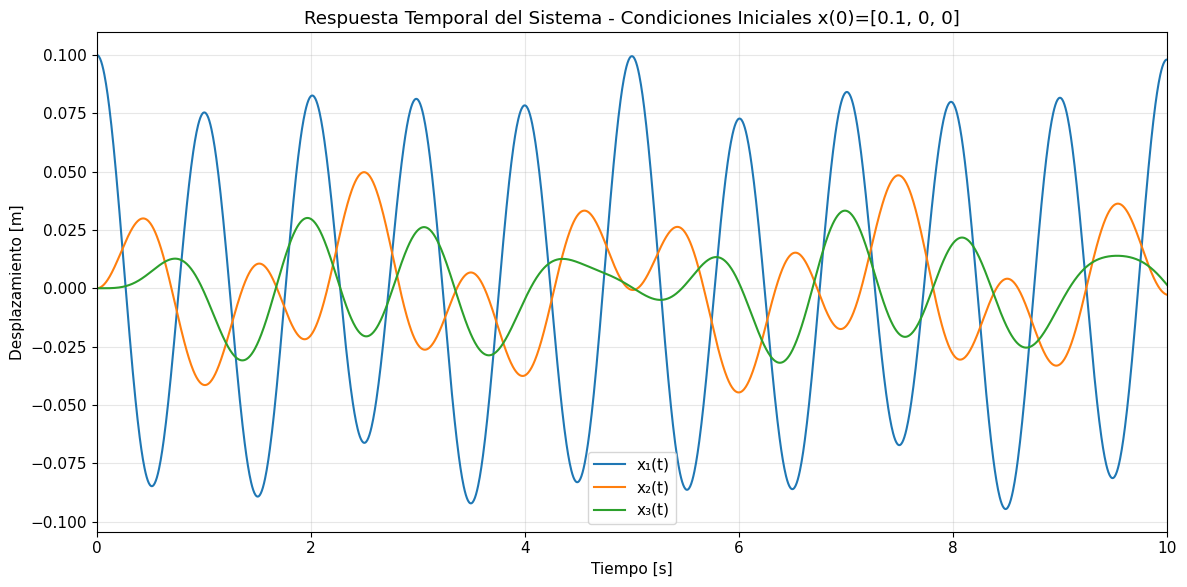

In [17]:
# Condiciones iniciales
x0 = np.array([0.1, 0.0, 0.0])
v0 = np.array([0.0, 0.0, 0.0])

# Coordenadas modales iniciales: q(0) = Φ^T M x(0)
q0 = Phi.T @ M @ x0
dq0 = Phi.T @ M @ v0

print("Coordenadas modales iniciales q(0):", np.round(q0, 6))
print("Velocidades modales iniciales q̇(0):", np.round(dq0, 6))

# Vector de tiempo
t = np.linspace(0, 10, 2000)

# Solución en coordenadas modales: q_n(t) = q0_n*cos(ω_n*t) + (dq0_n/ω_n)*sin(ω_n*t)
q_t = np.zeros((3, len(t)))
for i in range(3):
    q_t[i, :] = q0[i]*np.cos(omega[i]*t) + (dq0[i]/omega[i])*np.sin(omega[i]*t)

# Transformar al espacio físico: x(t) = Φ q(t)
x_t = Phi @ q_t

# Graficar
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, x_t[0, :], label='x₁(t)', linewidth=1.5)
ax.plot(t, x_t[1, :], label='x₂(t)', linewidth=1.5)
ax.plot(t, x_t[2, :], label='x₃(t)', linewidth=1.5)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Desplazamiento [m]')
ax.set_title('Respuesta Temporal del Sistema - Condiciones Iniciales x(0)=[0.1, 0, 0]')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

**Espectro de frecuencias naturales**

Comparación visual de las frecuencias y periodos obtenidos.

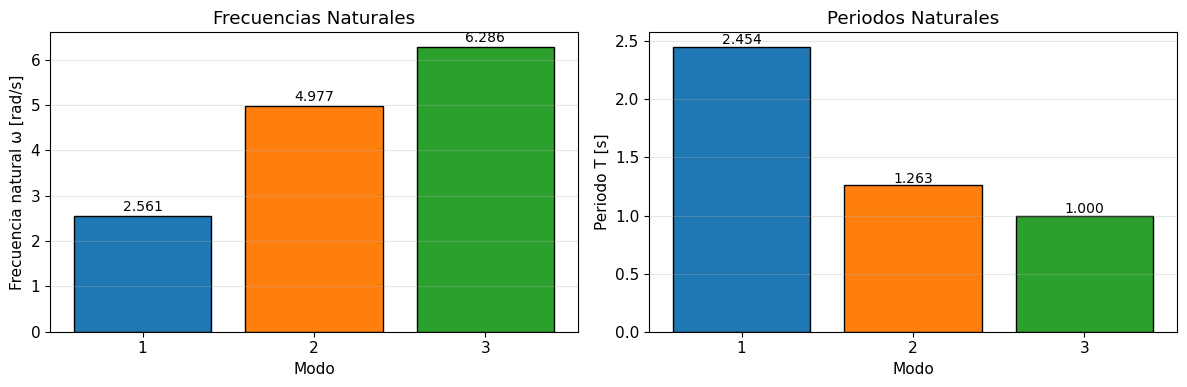

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
modes = [1, 2, 3]
ax1.bar(modes, omega, color=colors, edgecolor='black')
ax1.set_xticks(modes)
ax1.set_xlabel('Modo')
ax1.set_ylabel('Frecuencia natural ω [rad/s]')
ax1.set_title('Frecuencias Naturales')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(omega):
    ax1.text(i+1, v+0.1, f'{v:.3f}', ha='center', fontsize=10)

ax2.bar(modes, T, color=colors, edgecolor='black')
ax2.set_xticks(modes)
ax2.set_xlabel('Modo')
ax2.set_ylabel('Periodo T [s]')
ax2.set_title('Periodos Naturales')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(T):
    ax2.text(i+1, v+0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Resumen de resultados

**Ecuaciones de movimiento obtenidas formalmente**

$$\begin{cases}
\ddot{x}_1 + 35x_1 - 15x_2 = 0 \\ 
\ddot{x}_2 - 7.5x_1 + 12.5x_2 - 5x_3 = 0 \\ 
\ddot{x}_3 - 6.667x_2 + 23.333x_3 = 0
\end{cases}$$

**Problema de autovalores**

$$K\mathbf{u} = \omega^2 M\mathbf{u}$$

**Resultados numéricos**

| Modo | λ [rad²/s²] | ω [rad/s] | f [Hz] | T [s] | Descripción cualitativa |
|------|-------------|-----------|--------|-------|------------------------|
| 1 | 6.5576 | 2.5608 | 0.4076 | 2.4536 | Fundamental: masas mayoritariamente en fase, $m_2$ de mayor amplitud |
| 2 | 24.7664 | 4.9766 | 0.7920 | 1.2625 | $m_1$ y $m_2$ en contrafase respecto a $m_3$ |
| 3 | 39.5093 | 6.2856 | 1.0004 | 0.9996 | Máxima complejidad: cambios de fase entre masas consecutivas |

**Matriz modal Φ** (modos normalizados respecto a $M$):

$$\Phi = \begin{bmatrix} -0.3325 & -0.2423 & -0.9114 \\ -0.6306 & -0.1653 & 0.2740 \\ -0.2506 & 0.7688 & -0.1129 \end{bmatrix}$$

**Observaciones clave:**
- Las matrices $M$ y $K$ son simétricas; $M$ es definida positiva (masas > 0) y $K$ es definida positiva (sistema estable).
- El problema de autovalores generalizado $K\mathbf{u} = \lambda M\mathbf{u}$ garantiza autovalores reales y positivos ($\lambda > 0$) y autovectores ortogonales respecto a $M$ y $K$.
- La superposición modal desacopla el sistema en 3 osciladores armónicos independientes.
- La respuesta a condiciones iniciales arbitrarias es una combinación lineal de los 3 modos, con amplitudes modales determinadas por la proyección de las CI sobre cada autovector.

---

### Apéndice: Código compacto de todo el análisis

Versión resumida del análisis completo en una única celda ejecutable:

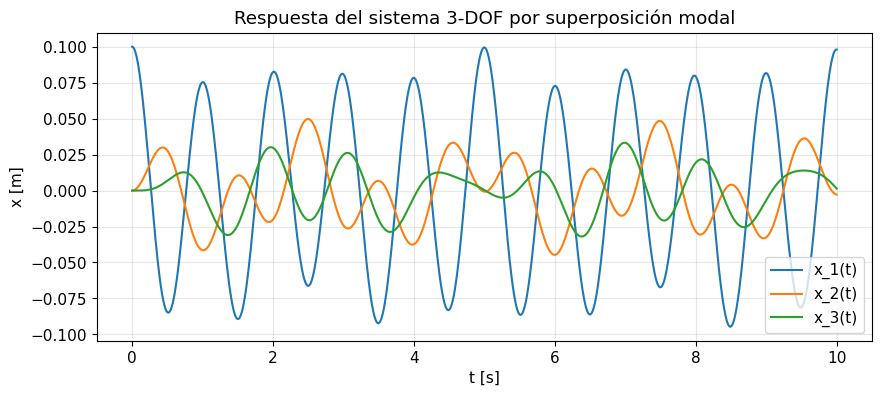

Frecuencias naturales [rad/s]: [2.5608 4.9766 6.2856]
Matriz modal Φ:
 [[-0.3325 -0.2423 -0.9114]
 [-0.6306 -0.1653  0.274 ]
 [-0.2506  0.7688 -0.1129]]


In [19]:
# ============================================
# ANÁLISIS MODAL COMPLETO - SISTEMA 3 DOF
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

# 1. Datos y matrices M, K
m = [1.0, 2.0, 1.5]
k = [20.0, 15.0, 10.0, 25.0]
M = np.diag(m)
K = np.array([[k[0]+k[1], -k[1], 0],
              [-k[1], k[1]+k[2], -k[2]],
              [0, -k[2], k[2]+k[3]]])

# 2. Autovalores generalizados: K u = λ M u
lam, U = eig(K, M)
idx = np.argsort(lam)
lam, U = np.real(lam[idx]), U[:, idx]
w = np.sqrt(lam)

# 3. Normalizar modos respecto a M
Phi = np.zeros_like(U)
for i in range(3):
    u = np.real(U[:, i])
    Phi[:, i] = u / np.sqrt(u.T @ M @ u)

# 4. Respuesta temporal por superposición modal
x0 = np.array([0.1, 0, 0])
q0 = Phi.T @ M @ x0
t = np.linspace(0, 10, 2000)
q = np.array([q0[i]*np.cos(w[i]*t) for i in range(3)])
x = Phi @ q

# 5. Gráfico
plt.figure(figsize=(10,4))
[plt.plot(t, x[i], label=f'x_{i+1}(t)') for i in range(3)]
plt.xlabel('t [s]'); plt.ylabel('x [m]')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Respuesta del sistema 3-DOF por superposición modal')
plt.show()

print("Frecuencias naturales [rad/s]:", w)
print("Matriz modal Φ:\n", np.round(Phi, 4))